# Embeddings

- Master AAI - Hogeschool van Amsterdam
- Docenten:  Michiel Bontenbal & Rick van Kersbergen
- Donderdag 25 september 2025
- This notebook has been tested with **Python 3.11 and 3.12**

In this notebook you learn about two applications for cosine similarity: finding similar images and clustering similar images.

First, we'll get an understanding how the maths for cosine similarity work using a basic example.
Next, we'll calculatie the similarity between two images.
Third, we'll find similar images from a set of images. 
And finally, we'll cluster images based on their similarity.

### Contents
1. Intro:  calculate the cosine similarity (nl: cosinusgelijkenis)
2. Calculate cosine similarity for 2 images
3. Find similar images with cosine similarity
4. Do PCA analysis and visualise the embeddings
5. Store the embeddings in a vector database (FAISS)

### Sources
- https://nl.wikipedia.org/wiki/Cosinusgelijkenis
- https://openai.com/research/clip
- https://medium.com/@jeremy-k/unlocking-openai-clip-part-2-image-similarity-bf0224ab5bb0
- https://www.geeksforgeeks.org/how-to-calculate-cosine-similarity-in-python/
- https://www.geeksforgeeks.org/python-measure-similarity-between-two-sentences-using-cosine-similarity/

## 0. Install, imports and settings

In [4]:
%%capture
%pip install torch torchvision
%pip install git+https://github.com/openai/CLIP.git
%pip install plotly
%pip install nbformat
%pip install huggingface_hub

In [5]:
from PIL import Image
import torch
import torch.nn as nn
import clip
import warnings
import matplotlib.pyplot as plt
import os
import itertools
import glob
import numpy as np
from sklearn.decomposition import PCA
import plotly.express as px
from huggingface_hub import snapshot_download

warnings.filterwarnings('ignore')

# settings to prevent SSL certificate errors on some systems
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

#Set your hardware usage. Use cuda for Nvidia GPUs, mps for Apple Silicon, cpu otherwise.
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

/Users/frankvandervelde/.pyenv/versions/all_purpose/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Intro:  calculate the cosine similarity (nl: cosinusgelijkenis)

To calculate the cosine similarity we take to vectors (A,B). 
We then calculate their dotproduct and devide it by the product of the normalized vectors. 

cos(θ) = (A · B) / (||A|| ||B||)
)

In [6]:
#Define two points

# Choose values [1-10] (integers/floats) to properly plot it below

# point 1
p1x = 4
p1y = 3

#point 2
p2x = 3
p2y = 4

In [32]:
#function to calculate cosine similarity
def cosine_similarity(a, b):
    dot_product = sum(x * y for x, y in zip(a, b))
    magnitude_a = sum(x * x for x in a) ** 0.5
    magnitude_b = sum(x * x for x in b) ** 0.5
    return dot_product / (magnitude_a * magnitude_b)

cos_sim = cosine_similarity((p1x,p1y), (p2x,p2y))
print(f'Cosine similarity:  {cos_sim}')

Cosine similarity:  1.0


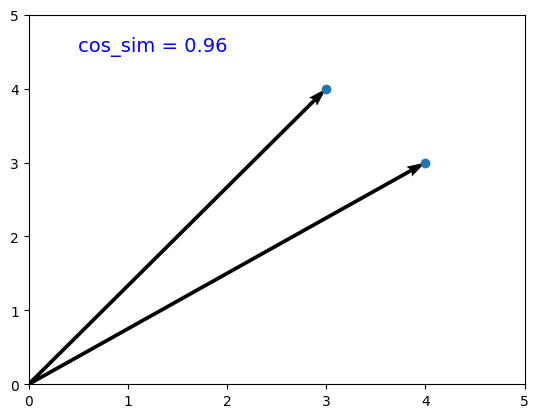

In [8]:
#plot the points and create a vector from 0,0
%matplotlib inline
import matplotlib.pyplot as plt 

#get points and plot them
points_x = p1x, p2x
points_y = p1y, p2y
plt.plot(points_x, points_y, 'o') 

#plot vectors 
plt.quiver([0, 0], [0, 0], [p1x, p2x], [p1y,p2y], angles='xy', scale_units='xy', scale=1)

#plot axes and show it
plt.xlim(0, 5)
plt.ylim(0, 5)

# Display the value of cos_sim in the plot
plt.text(0.5, 4.5, f'cos_sim = {cos_sim:.2f}', fontsize=14, color='blue')

plt.show()

### Exercise 1: 
1. play with the points in the first code cell and see what happens
2. create two examples:
    - Where cosine similarity is 1
    - Where cosine similarity is 0

In [36]:
# Result cosine similarity is 1

# point 1
p1x = 1
p1y = 1

#point 2
p2x = 1
p2y = 1


cos_sim = cosine_similarity((p1x,p1y), (p2x,p2y))
print(f'Cosine similarity:  {cos_sim}')

Cosine similarity:  1.0


In [37]:
# Result cosine similarity is 0

# point 1
p1x = -1
p1y = -1

#point 2
p2x = 1
p2y = 1

cos_sim = cosine_similarity((p1x,p1y), (p2x,p2y))
print(f'Cosine similarity:  {cos_sim}')

Cosine similarity:  -1.0


## 2. Calculate cosine similarity for 2 images

Here we will use two images and calculate how similar they are. 

To do so we'll create embeddings using CLIP. CLIP as several methods of creating embeddings, but here we'll use a standard Vision Transformer (ViT).

In [30]:
# import packages
from PIL import Image
import torch
import torch.nn as nn
import clip


#select embedding model
model, preprocess = clip.load("ViT-B/32", device=device) # we use a Vision Transformer (ViT) for the embeddings

100%|███████████████████████████████████████| 338M/338M [00:26<00:00, 13.4MiB/s]



We will download the image dataset from Huggingface. Normally you do this with Hugginface Datasets package, but for now it's easier to clone the dataset as you can easily manually inspect and display the images. 

In [ ]:
# Use the snapshot_download function to download the repository as files

from huggingface_hub import snapshot_download

# Download the entire repository
snapshot_download(
    repo_id="MichielBontenbal/sim_search_mini",
    repo_type="dataset",
    local_dir="./sim_search_mini",
    local_dir_use_symlinks=False  # This ensures actual files, not symlinks
)

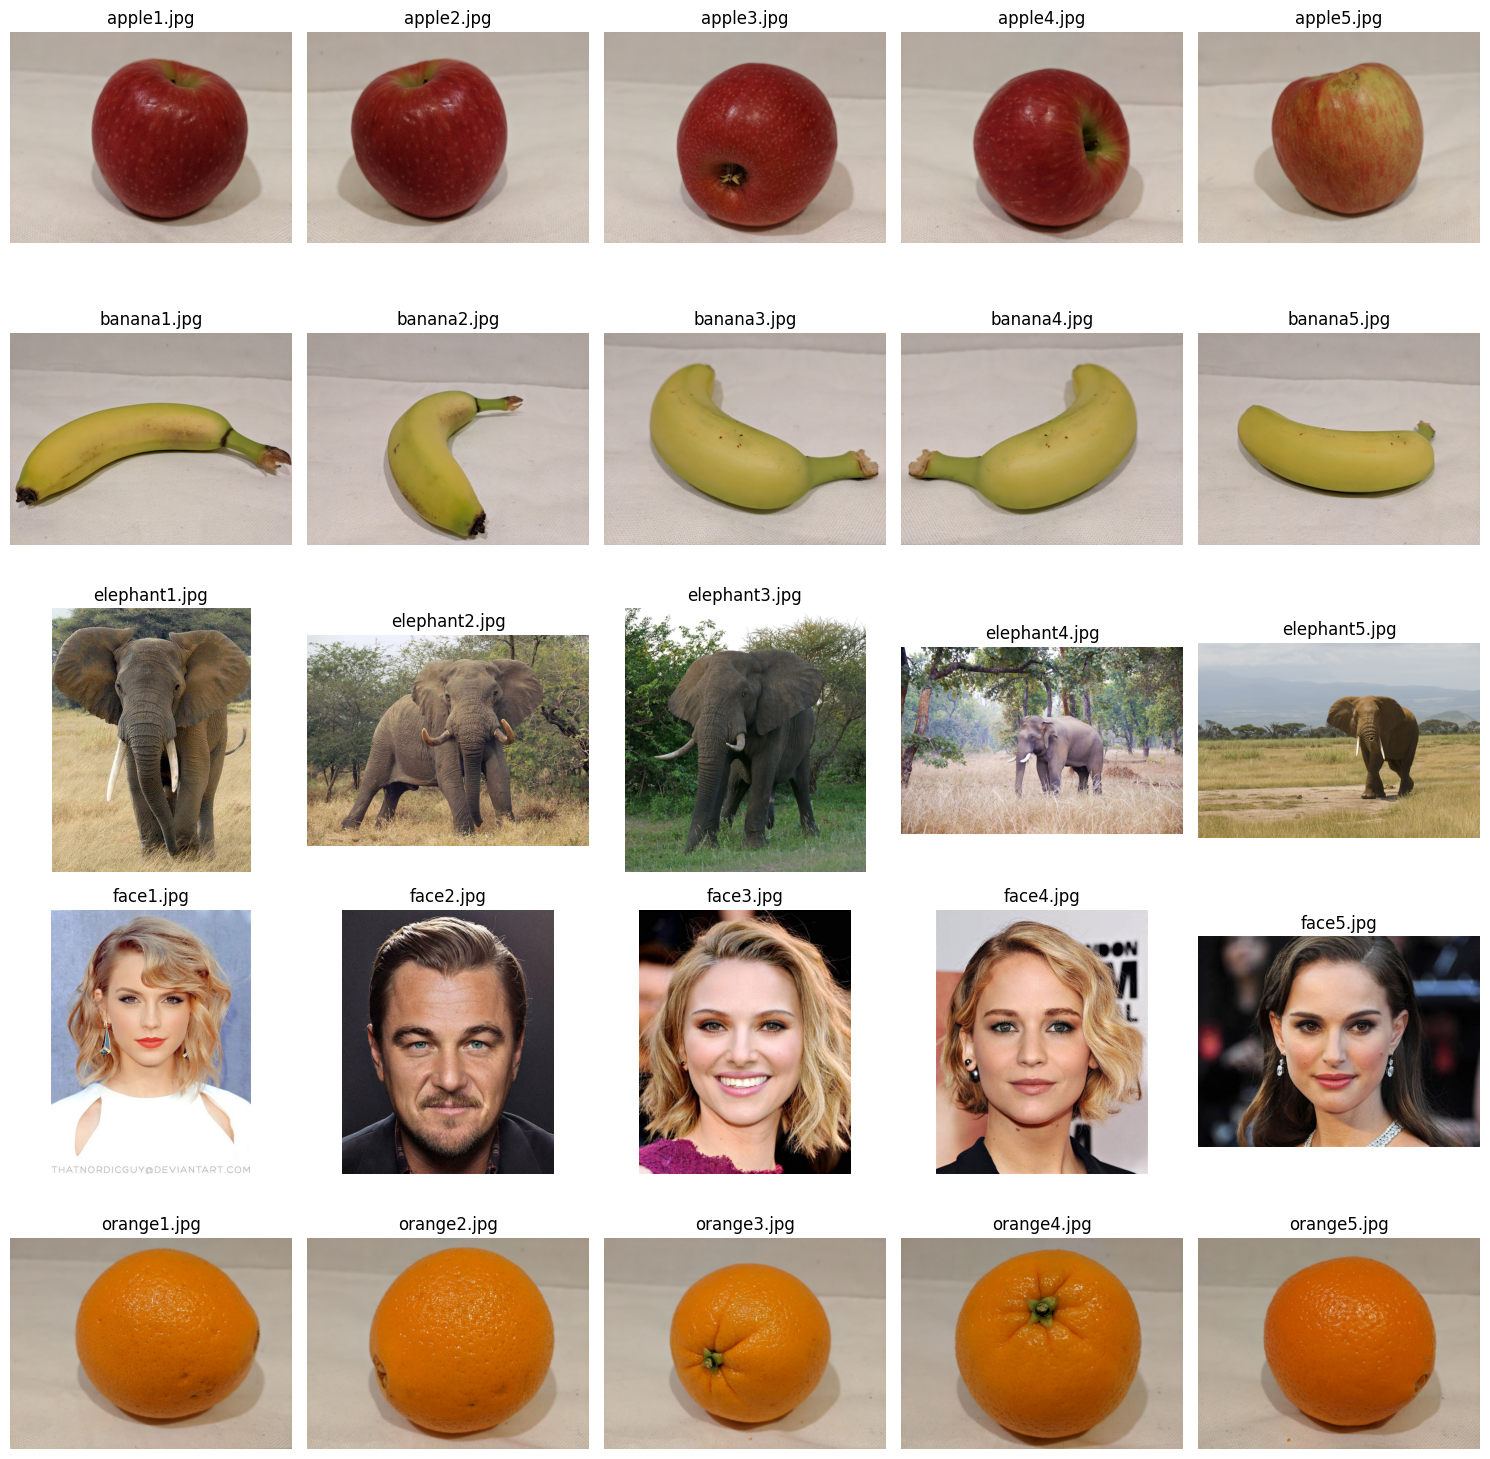

In [39]:
# Display 25 images in a grid in the notebook
import matplotlib.pyplot as plt
import os
from PIL import Image
image_folder = "sim_search_mini"
image_files = sorted([f for f in os.listdir(image_folder) if f.endswith('.jpg')])[:25]
plt.figure(figsize=(15, 15))
for i, img_file in enumerate(image_files):
    img = Image.open(os.path.join(image_folder, img_file))
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_file)
plt.tight_layout()
plt.show()

In [40]:
#select two images
image1 = "./sim_search_mini/apple1.jpg"
image2= "./sim_search_mini/apple2.jpg"

In [41]:
#Do preprocessing and create embeddings for the images
image1_preprocess = preprocess(Image.open(image1)).unsqueeze(0).to(device)
image1_features = model.encode_image(image1_preprocess)

image2_preprocess = preprocess(Image.open(image2)).unsqueeze(0).to(device)
image2_features = model.encode_image( image2_preprocess)

# EXERCISE 2a
Inspect the embeddings your created. 
Print the shape and the datatype.

In [42]:
#YOUR CODE HERE
# hint gebruik eventueel dir(image1_features)

# Print the shape and datatype of the embeddings
print("Shape of image1_features:", image1_features.shape)
print("Datatype of image1_features:", image1_features.dtype)
print("Device of image1_features:", image1_features.device)

# Also show the shape and datatype of image2_features for comparison
print("\nShape of image2_features:", image2_features.shape)
print("Datatype of image2_features:", image2_features.dtype)
print("Device of image2_features:", image2_features.device)

# Optional: show some additional information
print(f"\nNumber of elements in embedding: {image1_features.numel()}")
print(f"Embedding dimensions: {image1_features.shape}")

Shape of image1_features: torch.Size([1, 512])
Datatype of image1_features: torch.float16
Device of image1_features: mps:0

Shape of image2_features: torch.Size([1, 512])
Datatype of image2_features: torch.float16
Device of image2_features: mps:0

Number of elements in embedding: 512
Embedding dimensions: torch.Size([1, 512])


In [43]:
#calculate the cosine similarity
cos = torch.nn.CosineSimilarity(dim=0)

similarity = cos(image1_features[0],image2_features[0]).item()
similarity = (similarity+1)/2

print("Image 1: ", image1)
print("Image 2: ", image2)
print("Image similarity: ", similarity)

Image 1:  ./sim_search_mini/apple1.jpg
Image 2:  ./sim_search_mini/apple2.jpg
Image similarity:  0.99853515625


## Exercise 2b: 
Calculate cosine similarity for images of an apple and an elephant.

## 3. Find similar images with cosine similarity

In [45]:
import torch
import clip
from PIL import Image
import os
import itertools
import torch.nn as nn


model, preprocess = clip.load("ViT-B/32", device=device)

print(device)

dataset_folder = './sim_search_mini/'

images = []
for root, dirs, files in os.walk(dataset_folder):
    for file in files:
        if file.endswith(('jpg','jpeg')):
            images.append(  root  + '/'+ file)


#Embedding of the input image
original_image = './sim_search_mini/face1.jpg'
input_image = preprocess(Image.open(original_image)).unsqueeze(0).to(device) #
input_image_features = model.encode_image(input_image)

result = {}
for img in images:
    with torch.no_grad():
        image_preprocess = preprocess(Image.open(img)).unsqueeze(0).to(device)
        image_features = model.encode_image( image_preprocess)
        cos = torch.nn.CosineSimilarity(dim=0)
        sim = cos(image_features[0],input_image_features[0]).item()
        sim = (sim+1)/2
        result[img]=sim


sorted_value = sorted(result.items(), key=lambda x:x[1], reverse=True)
sorted_results = dict(sorted_value)

top_3 = dict(itertools.islice(sorted_results.items(), 3))

print(top_3)

mps
{'./sim_search_mini//face1.jpg': 1.0, './sim_search_mini//face3.jpg': 0.880859375, './sim_search_mini//face4.jpg': 0.8759765625}
{'./sim_search_mini//face1.jpg': 1.0, './sim_search_mini//face3.jpg': 0.880859375, './sim_search_mini//face4.jpg': 0.8759765625}


The original image is:


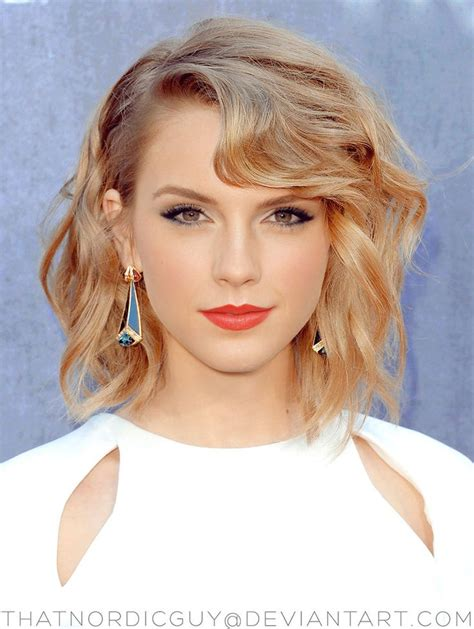

The duplicate is: 


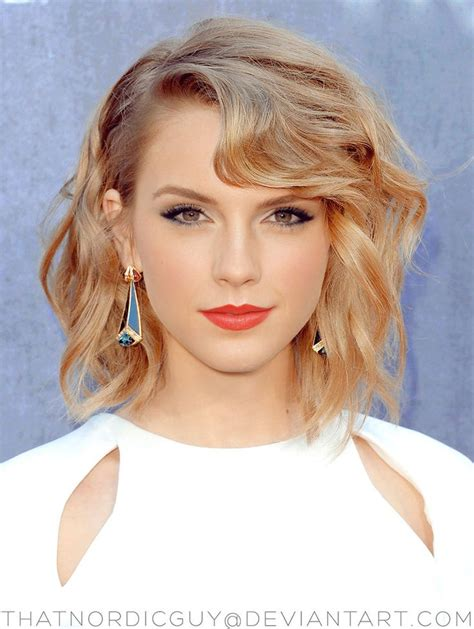

And the most similar images are:


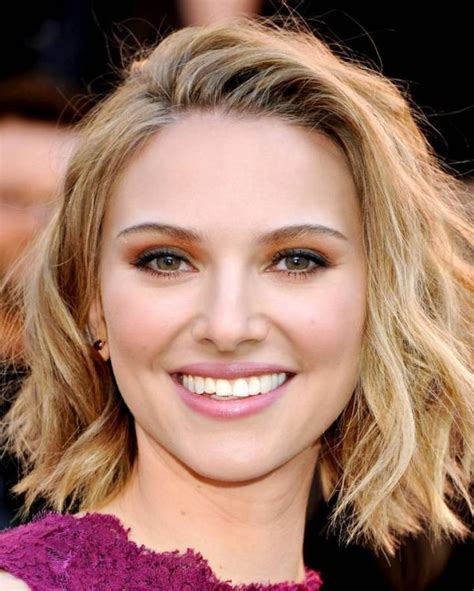

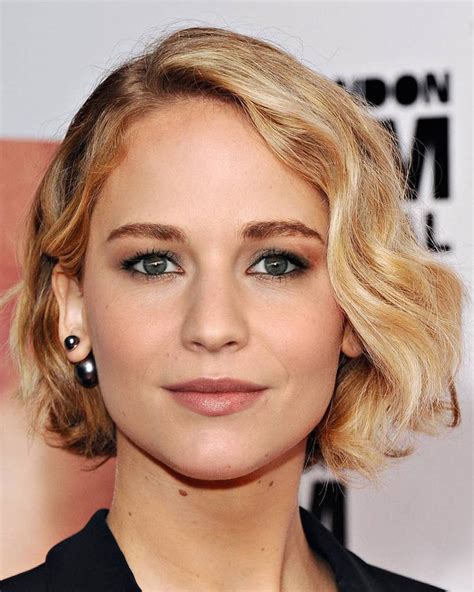

In [46]:
#display most similar images

from IPython.display import Image, display

first = list(top_3.keys())[0]
second = list(top_3.keys())[1]
third = list(top_3.keys())[2]

print("The original image is:")
display(Image(original_image, width = 200))
print('The duplicate is: ')
display(Image(first, width = 200) )
print('And the most similar images are:')
display(Image(second, width = 200), Image(third, width = 200))

## Exercise 3:
Get the image that is least similar to the original image. 

In [ ]:
# Select the least similar image and display it
# Hint: use the dictionary 'sorted_results' 

## 4. Visualise the embeddings with Principal Component Analysis (PCA)

Met PCA kunnen we het aantal dimensies van de embedding terugbrengen tot 2. 
We kunnen dan de dimensies projecteren in een x,y diagram. 
Zo kan je de embeddings visualiseren.
De code hieronder krijg je cadeau. 
Naast PCA zou je ook T-SNE of UMAP algoritmes hiervoor kunnen gebruiken. Voor een kleine dataset als deze (n=25) is PCA voldoende.


In [ ]:
#assign all images to a python list
import glob
my_images = glob.glob('./sim_search_mini/*.jpg')
len(my_images)

In [ ]:
#get the labels from the filename
labels_list=[]
for i in range(len(my_images)):
    filename = my_images[i].split('/')[-1].split('.')[0]
    label = ''.join([c for c in filename if not c.isdigit()])
    labels_list.append(label)

In [ ]:
import torch
import numpy as np
from PIL import Image

def get_embeddings(i):
    global embedding_np
    img= my_images[i]
    image_preprocess = preprocess(Image.open(img)).unsqueeze(0).to(device)
    image_features = model.encode_image(image_preprocess)
    embedding = image_features
    embedding_np = np.array(embedding.detach().cpu().numpy())
    return embedding_np

#get_embeddings(my_images[0])

In [ ]:
#Create one array with all the embeddings
import numpy as np

combined_array = np.empty((0, 512))

for i in range(len(my_images)):
   get_embeddings(i) 
   combined_array = np.vstack((combined_array, embedding_np))

#Check the shape of the array
print(combined_array.shape)


In [ ]:
# Apply PCA to reduce dimensions to 2 dimensions

from sklearn.decomposition import PCA

pca = PCA(n_components=2)  # Reduce to 2 dimensions
embeddings_pca = pca.fit_transform(combined_array)



In [ ]:
import plotly.express as px
import numpy as np

# Assuming you have a list of class labels corresponding to each point
# If you don't have this, you'll need to create it based on your data
class_labels = labels_list
# Create a color map for the 5 classes
color_map = px.colors.qualitative.Set1[:5]

fig = px.scatter(
    x=embeddings_pca[:, 0],
    y=embeddings_pca[:, 1],
    color=class_labels,
    color_discrete_sequence=color_map,
    opacity=0.7,
    title='Visualisation of embeddings with PCA',
    #labels={'color': 'Class'}
    hover_name=[img.split('/')[-1] for img in my_images]  # Add filenames as hover text
)

fig.update_traces(marker=dict(size=8))

fig.show()



We've succesfully visualised the CLIP embeddings. We've created embeddings for each image, we've calculated the cosine similarity between images in an N-dimensional space. We've then done Principal Component Analysis to reduce the dimensions.  

## 5. Store embeddings in FAISS Vector Database

Now we'll store our embeddings in a FAISS (Facebook AI Similarity Search) vector database. FAISS is optimized for similarity search and clustering of dense vectors, making it perfect for our image embeddings.

We'll create a FAISS index, add our embeddings to it, and then perform similarity searches.

In [ ]:
# Install FAISS
%pip install faiss-cpu

In [ ]:
import faiss
import numpy as np

# Create a FAISS index for our embeddings
# We use L2 (Euclidean) distance, but we could also use inner product for cosine similarity
dimension = combined_array.shape[1]  # 512 dimensions from CLIP ViT-B/32
print(f"Creating FAISS index with {dimension} dimensions")

# Create an L2 index (Euclidean distance)
index = faiss.IndexFlatL2(dimension)

# Add embeddings to the index
# Convert to float32 as required by FAISS
embeddings_float32 = combined_array.astype('float32')
index.add(embeddings_float32)

print(f"Added {index.ntotal} embeddings to FAISS index")
print(f"Index is trained: {index.is_trained}")

### Reflection questions

#### 1. Write down the steps you did to get to the PCA analysis


#### 2. Describe an embedding in your own words


#### 3: Hard question. How can we speed up the calculation of the cosine similarity?
Hint: check the datatype of the embedding. 



